# Building RAG Chatbots for Technical Documentation
## Project Description
You'll create a context-aware chatbot by integrating a car manual with an LLM using LangChain and Retrieval Augmented Generation (RAG). The goal is to create a car assistant that can explain dashboard warnings and recommend actions while driving. Say goodbye to boring manuals!

## Project Instructions
The car manual HTML document has been loaded for you as `car_docs`. Using Retrieval Augmented Generation (RAG) to make OpenAI's `gpt-4o-mini` aware of the contents of `car_docs`, answer the following user query:
```
"The Gasoline Particular Filter Full warning has appeared. What does this mean and what should I do about it?"
```
- Store the answer to the user query in the variable `answer`.

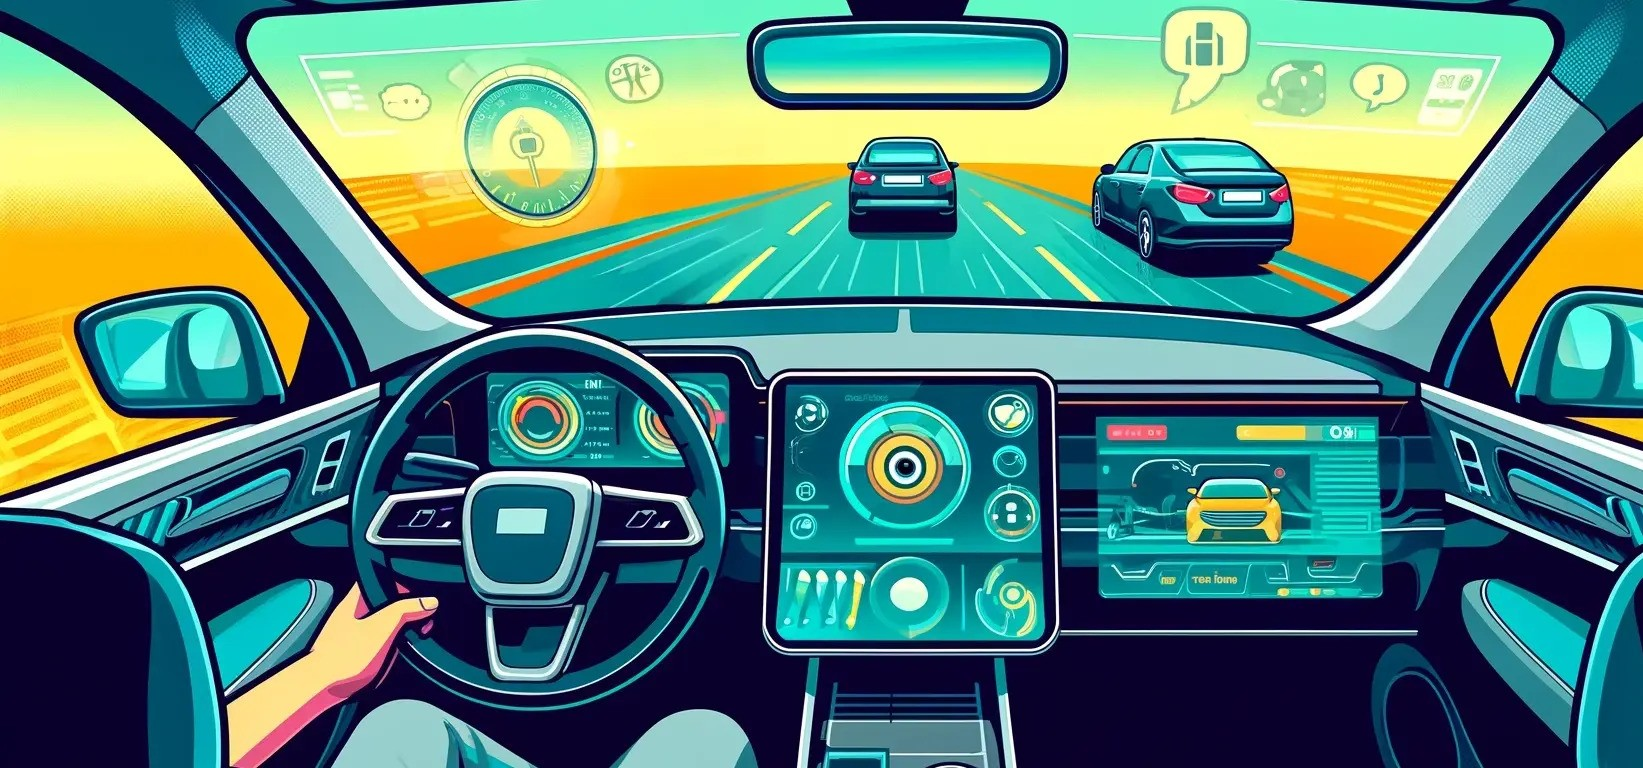
You're working for a well-known car manufacturer who is looking at implementing LLMs into vehicles to provide guidance to drivers. You've been asked to experiment with integrating car manuals with an LLM to create a context-aware chatbot. They hope that this context-aware LLM can be hooked up to a text-to-speech software to read the model's response aloud.

As a proof of concept, you'll integrate several pages from a car manual that contains car warning messages and their meanings and recommended actions. This particular manual, stored as an HTML file, mg-zs-warning-messages.html, is from an MG ZS automobile, a compact SUV. Armed with your newfound knowledge of LLMs and LangChain, you'll implement Retrieval Augmented Generation (RAG) to create the context-aware chatbot.

**Note: Although we'll be using the OpenAI API in this project, you do not need to specify an API key.**

In [ ]:
# Run this cell to install the necessary packages
import subprocess
import pkg_resources

def install_if_needed(package, version):
    '''Function to ensure that the libraries used are consistent to avoid errors.'''
    try:
        pkg = pkg_resources.get_distribution(package)
        if pkg.version != version:
            raise pkg_resources.VersionConflict(pkg, version)
    except (pkg_resources.DistributionNotFound, pkg_resources.VersionConflict):
        subprocess.check_call(["pip", "install", f"{package}=={version}"])

install_if_needed("langchain-core", "0.3.72")
install_if_needed("langchain-openai", "0.3.28")
install_if_needed("langchain-community", "0.3.27")
install_if_needed("unstructured", "0.18.11")
install_if_needed("langchain-chroma", "0.2.5")
install_if_needed("langchain-text-splitters", "0.3.9")
install_if_needed("pydantic", "2.11.9")

In [ ]:
# Import the required packages
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import UnstructuredHTMLLoader
from langchain_core.runnables import RunnablePassthrough
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
import os

In [ ]:
# Load the HTML as a LangChain document loader
loader = UnstructuredHTMLLoader(file_path="data/mg-zs-warning-messages.html")
car_docs = loader.load()

In [ ]:
# Load the models required to complete the exercise
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small", openai_api_key=os.environ["OPENAI_API_KEY"])

In [ ]:
# Initialize RecursiveCharacterTextSplitter to make chunks of HTML text
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)

In [ ]:
# Split the car documents with text_splitter
splits = text_splitter.split_documents(car_docs)

In [ ]:
# Initialize Chroma vectorstore with documents as splits and using OpenAIEmbeddings
vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings)

In [ ]:
# Setup vectorstore as retriever
retriever = vectorstore.as_retriever()

In [ ]:
# Define RAG prompt
prompt = ChatPromptTemplate.from_template("You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:")

In [ ]:
# Setup the chain
rag_chain = (
    {"context": retriever , "question": RunnablePassthrough()}
    | prompt
    | llm
)

In [ ]:
# Initialize query
query = "The Gasoline Particular Filter Full warning has appeared. What does this mean and what should I do about it?"

In [ ]:
# Invoke the query
answer = rag_chain.invoke(query).content
print(answer)